In [1]:
from argparse import ArgumentParser
import xarray as xr
from matplotlib import pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys

sys.path.insert(
    1, "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation"
)
import plot_utils as plot
import distribution_analysis as dist
import numpy as np

save_folder = "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/new_rmse_values/"


def create_folder_if_not_exists(folder):
    from pathlib import Path

    Path(folder).mkdir(parents=True, exist_ok=True)


def get_temporal_index_in_dataset(timestamp, ds):
    """
    Returns the integer index of a given timestamp in an xarray Dataset
    that may use non-Gregorian calendars (e.g., 360_day).

    timestamp: cftime.Datetime object or a string parseable by cftime
    ds: xarray.Dataset or DataArray with a 'time' coordinate
    """

    # Iterate over time coordinates to find match
    for i, t in enumerate(ds.time.values):
        if t == timestamp:
            return i

    # If not found, raise error
    raise ValueError(f"Timestamp {timestamp} not found in dataset time axis.")


def get_true_data_matching_forecast_timestamps(
    ds_truth, ds_forecast, prediction_steps
):
    """
    prediction_steps should be 0 based -> 0 means using the first prediction of the model for that timestamp
    """
    first_timestamp_forecast = ds_forecast.time[0].values
    last_timestamp_forecast = ds_forecast.time[-1].values
    idx_truth_first = (
        get_temporal_index_in_dataset(first_timestamp_forecast, ds_truth)
        + prediction_steps
        + 1
    )
    idx_truth_last = (
        get_temporal_index_in_dataset(last_timestamp_forecast, ds_truth)
        + prediction_steps
        + 1
    )
    new_forecast = ds_forecast.copy().isel(
        prediction_timedelta=prediction_steps
    )
    new_truth = ds_truth.isel(
        time=slice(idx_truth_first, idx_truth_last + 1)
    ).isel(time=slice(0, None, 2))
    new_forecast = new_forecast.sortby("time")
    _, index = np.unique(new_forecast["time"], return_index=True)
    new_forecast = new_forecast.isel(time=np.sort(index))

    for t in range(len(new_forecast.time.values) - 1):
        if (
            not str(
                new_forecast.time.values[t + 1] - new_forecast.time.values[t]
            )
            == "12:00:00"
        ):
            print(
                f"Error with {new_forecast.time.values[t]} and {new_forecast.time.values[t+1]}"
            )
    new_forecast = new_forecast.assign_coords({"time": new_truth["time"]})
    return new_truth, new_forecast


def get_stacked_true_data_matching_forecast_timestamps(ds_truth, ds_forecast):
    """
    prediction_steps should be 0 based -> 0 means using the first prediction of the model for that timestamp
    """
    first_timestamp_forecast = ds_forecast.time[0].values
    last_timestamp_forecast = ds_forecast.time[-1].values
    idx_truth_first = get_temporal_index_in_dataset(
        first_timestamp_forecast, ds_truth
    )
    idx_truth_last = get_temporal_index_in_dataset(
        last_timestamp_forecast, ds_truth
    )
    new_forecast = ds_forecast.copy()
    new_truth = ds_truth.isel(
        time=slice(idx_truth_first, idx_truth_last + 1)
    ).isel(time=slice(0, None, 2))
    new_forecast = new_forecast.sortby("time")
    _, index = np.unique(new_forecast["time"], return_index=True)
    new_forecast = new_forecast.isel(time=np.sort(index))
    new_forecast = new_forecast.chunk({"latitude": -1, "longitude": -1, "time": 50})
    new_truth = new_truth.chunk({"latitude": -1, "longitude": -1, "time": 50})
    # for t in range(len(new_forecast.time.values)-1):
    #     if not str(new_forecast.time.values[t+1] - new_forecast.time.values[t]) == '12:00:00':
    #         print(f'Error with {new_forecast.time.values[t]} and {new_forecast.time.values[t+1]}')
    # new_forecast = new_forecast.assign_coords({'time': new_truth['time']})
    return new_truth, new_forecast


def build_truth_with_leadtime(truth_ds, max_lead_steps=40):
    """
    truth_ds: Dataset with dimension (time, lat, lon, level)
    Creates a dataset with dimension (time, prediction_timedelta, lat, lon, level)

    lead step k uses truth_ds shifted by k steps forward in time.
    """
    truth_ds = truth_ds.chunk({"time": 50})
    lead_times = np.arange(1, max_lead_steps + 1)

    # Build stacked truth array
    truth_list = []
    for k in lead_times:
        truth_shifted = truth_ds.shift(
            time=-k
        )  # shift backwards so truth[t,k] = truth[t+k]
        truth_list.append(truth_shifted)

    # Combine along new dimension
    truth_with_lead = xr.concat(truth_list, dim="prediction_timedelta")

    # Assign actual timedelta
    truth_with_lead = truth_with_lead.assign_coords(
        prediction_timedelta=xr.DataArray(
            (lead_times * np.timedelta64(6, "h")).astype("timedelta64[ns]"),
            dims=("prediction_timedelta",),
        )
    )

    # Drop times near the end that became NaN
    truth_with_lead = truth_with_lead.dropna(dim="time", how="any")

    return truth_with_lead

def get_datasets_after(ds_true, ds_forecast, hours_into_future=None, days_into_future=None):
    steps=-1
    if days_into_future:
        steps+=4*days_into_future
    if hours_into_future:
        if not hours_into_future%6 == 0:
            print(f'    Warning, given hours: {hours_into_future} cannot be divided by step length (6)')
        steps+=int(hours_into_future/6)
    if steps == -1:
        steps=0
        print(f'    No valid length provided, setting steps={steps} (=={(steps+1)*6} hours)')
    else:
        print(f'    Starting with a step length of {steps} (=={(steps+1)*6} hours)')
    return (get_true_data_matching_forecast_timestamps(ds_true, ds_forecast, steps))

In [2]:
import pickle
load=True
min_max_values = []
save_name = 'min_max_values_ukesm'

with open(f"{save_name}.pkl", "rb") as f:
    min_max_values = pickle.load(f)
print(min_max_values)

[(array(4261.216, dtype=float32), array(6023.9067, dtype=float32)), (array(221.86797, dtype=float32), array(315.26984, dtype=float32)), (array(3.222354e-07, dtype=float32), array(0.01465718, dtype=float32)), (array(184.01956, dtype=float32), array(323.84357, dtype=float32)), (array(-48.01496, dtype=float32), array(46.59402, dtype=float32)), (array(-50.76005, dtype=float32), array(55.128834, dtype=float32)), (array(0., dtype=float32), array(115.44497, dtype=float32)), (array(-0.0004987, dtype=float32), array(0.00039846, dtype=float32))]


In [3]:
print(min_max_values)

[(array(4261.216, dtype=float32), array(6023.9067, dtype=float32)), (array(221.86797, dtype=float32), array(315.26984, dtype=float32)), (array(3.222354e-07, dtype=float32), array(0.01465718, dtype=float32)), (array(184.01956, dtype=float32), array(323.84357, dtype=float32)), (array(-48.01496, dtype=float32), array(46.59402, dtype=float32)), (array(-50.76005, dtype=float32), array(55.128834, dtype=float32)), (array(0., dtype=float32), array(115.44497, dtype=float32)), (array(-0.0004987, dtype=float32), array(0.00039846, dtype=float32))]


In [4]:
model_idx=2

model_resolution = [
    "z64",
    "z128",
    "z256",
    "z64 hierarchical",
    "persistence",
]

current_model_resolution = model_resolution[model_idx]

selected_model_future = plot.FUTURE_MODELS_UKESM[model_idx]
print(f'Evaluating model: {selected_model_future["model_name"]}')

base_save_folder_future = selected_model_future["plot_folder"]

ukesm_future_forecasts = plot.open_zarr_ukesm(
    selected_model_future["forecasts"]
)

ukesm_future_truth = plot.open_zarr_ukesm(
    selected_model_future["ground_truth"]
)

create_folder_if_not_exists(base_save_folder_future)

steps = [5 * 24]
hours_into_future=steps[0]

truth_ds, forecast_ds = (
        get_datasets_after(ukesm_future_truth, ukesm_future_forecasts, hours_into_future)
    )

print("Preparing weights...")
lat = truth_ds["latitude"]
weights = np.cos(np.deg2rad(lat))
weights = xr.DataArray(weights, coords={"latitude": lat}, dims=["latitude"])
weights = weights / weights.sum()


Evaluating model: UKESM z256 Multi-Mesh
    Starting with a step length of 19 (==120 hours)
Preparing weights...


    Starting with a step length of 3 (==24 hours)
Current var: Geopotential at 500hPa
Multiplying data by 9.80665


/scratch/slurm_tmpdir/job_3716546/ipykernel_1655899/2381638351.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_to+'.png', bbox_inches="tight", dpi=400)
/software/all/jupyter/ai/2025-05-23/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


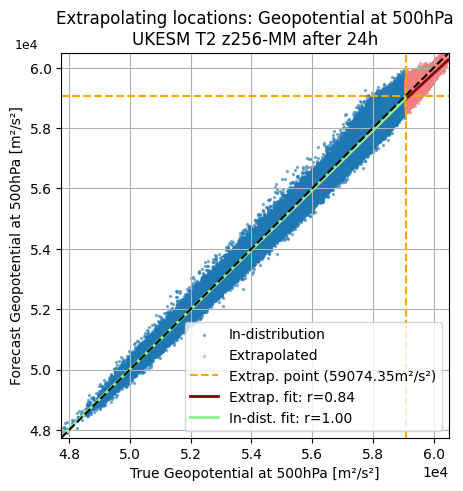

Current var: Specific Humidity at 700hPa


/scratch/slurm_tmpdir/job_3716546/ipykernel_1655899/2381638351.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_to+'.png', bbox_inches="tight", dpi=400)
/software/all/jupyter/ai/2025-05-23/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


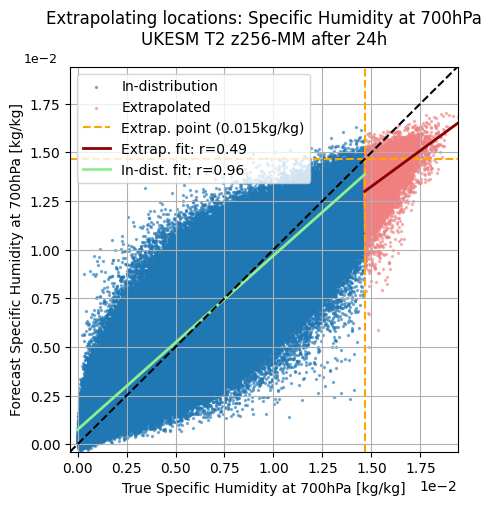

    Starting with a step length of 19 (==120 hours)
Current var: Geopotential at 500hPa
Multiplying data by 9.80665


/scratch/slurm_tmpdir/job_3716546/ipykernel_1655899/2381638351.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_to+'.png', bbox_inches="tight", dpi=400)
/software/all/jupyter/ai/2025-05-23/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


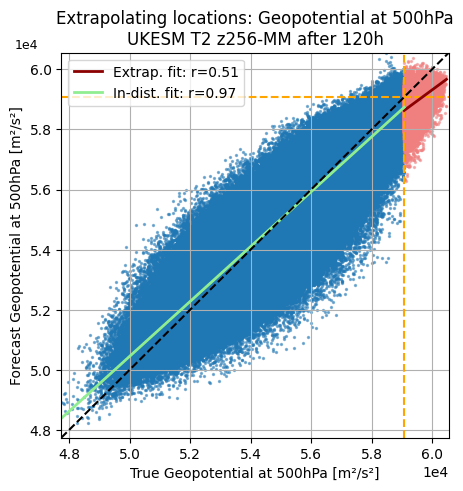

Current var: Specific Humidity at 700hPa


/scratch/slurm_tmpdir/job_3716546/ipykernel_1655899/2381638351.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_to+'.png', bbox_inches="tight", dpi=400)
/software/all/jupyter/ai/2025-05-23/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


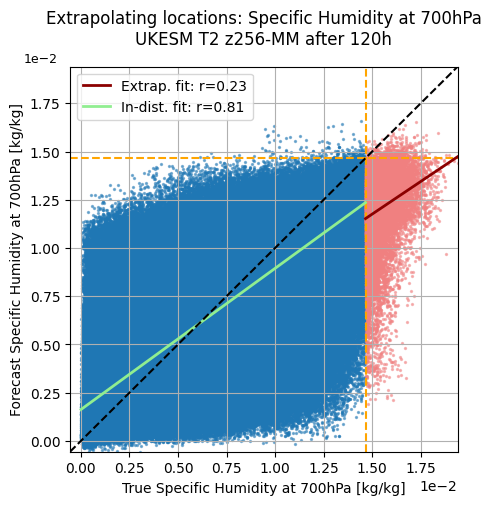

    Starting with a step length of 39 (==240 hours)
Current var: Geopotential at 500hPa
Multiplying data by 9.80665


/scratch/slurm_tmpdir/job_3716546/ipykernel_1655899/2381638351.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_to+'.png', bbox_inches="tight", dpi=400)
/software/all/jupyter/ai/2025-05-23/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


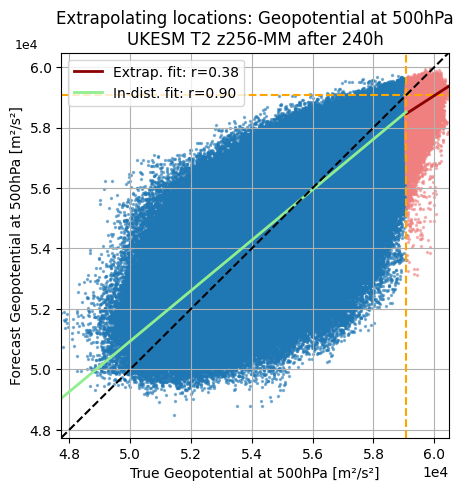

Current var: Specific Humidity at 700hPa


/scratch/slurm_tmpdir/job_3716546/ipykernel_1655899/2381638351.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_to+'.png', bbox_inches="tight", dpi=400)
/software/all/jupyter/ai/2025-05-23/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


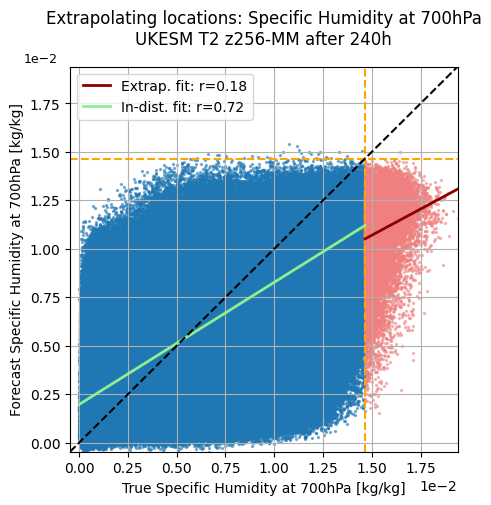

In [5]:
from scipy.stats import linregress, pearsonr
extrapolate_mask = xr.open_zarr('/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/extrapolation_future.zarr')
steps = [24, 5 * 24, 10*24]
# steps = [24]

for s in steps:
    hours_into_future=s
    
    
    truth_ds, forecast_ds = (
        get_datasets_after(ukesm_future_truth, ukesm_future_forecasts, hours_into_future)
    )
    
    # for key in range(len(plot.KEY_VARIABLES_UKESM)):
    for key in [0,2]:#range(1,len(plot.KEY_VARIABLES_UKESM)):
        display_name, unit, variable, plevel,_ = plot.KEY_VARIABLES_UKESM[key]
        if 'wind' in display_name.lower() or 'vorticity' in display_name.lower():
            continue
        max_value = min_max_values[key][1]
        if extrapolate_mask[variable].sum() == 0:
            continue
    
        print(f"Current var: {display_name}")
        # --- Select variable ---
        truth = truth_ds[variable].where(extrapolate_mask[variable])
        forecast = forecast_ds[variable].where(extrapolate_mask[variable])
        mult = plot.get_multiplier_ukesm(variable)
        if not mult == 1:
            print(f"Multiplying data by {mult}")
    
        # Select variable
        truth = truth * mult
        forecast = forecast * mult
        max_value = max_value * mult
    
        # --- Level selection ---
        if plevel is not None:
            truth = truth.sel(level=plevel)
            forecast = forecast.sel(level=plevel)
    
            if plevel > 500:
                truth = plot.get_masked_ukesm_data(
                    truth, plevel=plevel
                )
                forecast = plot.get_masked_ukesm_data(
                    forecast, plevel=plevel
                )
    
    
        import numpy as np
    
        # Flatten, remove NaNs, and align
        truth_vals = truth.values.flatten()
        forecast_vals = forecast.values.flatten()
        
        mask = ~np.isnan(truth_vals) & ~np.isnan(forecast_vals)
        truth_vals = truth_vals[mask]
        forecast_vals = forecast_vals[mask]
        
        extrap_mask = truth_vals > max_value
        x_extra = truth_vals[extrap_mask]
        y_extra = forecast_vals[extrap_mask]
        x_rest = truth_vals[~extrap_mask]
        y_rest = forecast_vals[~extrap_mask]
        
        if len(x_extra) > 1:  # only fit if we have enough points
            # Linear regression y = a*x + b
            slope, intercept, r_value, p_value, std_err = linregress(x_extra, y_extra)
            x_vals = np.linspace(x_extra.min(), x_extra.max(), 100)
        if len(x_rest) > 1:  # only fit if we have enough points
            # Linear regression y = a*x + b
            slope_r, intercept_r, r_value_r, p_value_r, std_err_r = linregress(x_rest, y_rest)
            x_vals_r = np.linspace(x_rest.min(), x_rest.max(), 100)
    
        plt.figure(figsize=(5, 5))
        
        # Normal points
        plt.scatter(
            truth_vals[~extrap_mask], forecast_vals[~extrap_mask],
            s=2, alpha=0.5, label="In-distribution" if s == 24 else None
        )
        
        # Extrapolated points
        plt.scatter(
            x_extra, y_extra,
            s=2, alpha=0.5, color='lightcoral', label="Extrapolated" if s == 24 else None
        )
        
        plt.axhline(y=max_value, color='orange', linestyle='--', linewidth=1.5, label=f'Extrap. point ({dist.format_value(max_value,unit)})' if s == 24 else None)
        plt.axvline(x=max_value, color='orange', linestyle='--', linewidth=1.5)

        if len(x_extra) > 1:
            plt.plot(
                x_vals,
                intercept + slope * x_vals,
                color='darkred', linewidth=2,
                label=f'Extrap. fit: r={r_value:.2f}'
            )
        if len(x_rest) > 1:
            plt.plot(
                x_vals_r,
                intercept_r + slope_r * x_vals_r,
                color='lightgreen', linewidth=2,
                label=f'In-dist. fit: r={r_value_r:.2f}'
            )
        
        plt.xlabel(f"True {display_name} [{unit}]")
        plt.ylabel(f"Forecast {display_name} [{unit}]")
        plt.title(f"Extrapolating locations: {display_name}\nUKESM T2 z256-MM after {hours_into_future}h")
        plt.grid(True)
        
        # 1:1 reference line
        lims = [
            min(truth_vals.min(), forecast_vals.min()),
            max(truth_vals.max(), forecast_vals.max())
        ]
        plt.plot(lims, lims, linestyle='--', color='black')
        plt.xlim(lims)
        plt.ylim(lims)
        plt.ticklabel_format(axis="y", style="sci", scilimits=(-2, 3))
        plt.ticklabel_format(axis="x", style="sci", scilimits=(-2, 3))
        ax = plt.gca()  # get current Axes
        offset = ax.yaxis.get_offset_text()
        offset.set_x(-0.12)
        offset.set_fontsize(9)
        plt.legend()
        save_to=f'/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/plots/extrapolation_scatter/z256_{variable}_after_{hours_into_future}'
        plt.savefig(save_to+'.png', bbox_inches="tight", dpi=400)
        #plt.savefig(save_to+'.pdf', bbox_inches="tight", dpi=600)
        plt.show()

    


In [ ]:

#     for key in range(var_start, len(plot.KEY_VARIABLES_UKESM)):
def compute_r2_for_variable(truth_ds, forecast_ds, key, weights, all_r2, r2_maps, past, current_model_resolution, var_start, fix_masks=False):
    display_name, _, variable, plevel,_ = plot.KEY_VARIABLES_UKESM[key]

    if fix_masks and ((not plevel) or (plevel <= 500)):
        print(f"Skipping {display_name} because of fix_masks==True")
        return


    print(f"Current var: {display_name}")
    # --- Select variable ---
    truth = truth_ds[variable]
    forecast = forecast_ds[variable]

    # --- Level selection ---
    if plevel is not None:
        truth = truth.sel(level=plevel)
        forecast = forecast.sel(level=plevel)

        if plevel > 500:
            truth = plot.get_masked_ukesm_data(
                truth, plevel=plevel
            )
            forecast = plot.get_masked_ukesm_data(
                forecast, plevel=plevel
            )

    # --- Broadcast weights ---
    # weights(lat) → (lat, lon)
    W2d = weights.broadcast_like(truth.isel(time=0, prediction_timedelta=0))

    # W2d → (time, lead, lat, lon)
    W = W2d.broadcast_like(truth)

    # --- Weighted mean for each lead time ---
    # dims: ('time','lat','lon')
    truth_mean = (truth * W).sum(dim=("latitude", "longitude")) / W.sum(
        dim=("latitude", "longitude")
    )


    # sum over time, lat, lon
    sse = ((truth - forecast) ** 2 * W).sum(
        dim=("time", "latitude", "longitude")
    )
    sst = ((truth - truth_mean) ** 2 * W).sum(dim=("time", "latitude", "longitude"))

    r2 = 1 - sse / sst

    # Convert xarray DataArray → numpy vector
    r2_values = r2.values  # shape (40,)
    all_r2[variable] = r2_values

    import pandas as pd

    df_r2 = pd.DataFrame(all_r2).T  # variables = rows, steps = columns
    df_r2.columns = [f"step_{i+1}" for i in range(40)]

    df_r2.to_csv(
        save_folder
        + f"r2_all_variables_{current_model_resolution}_{'past' if past else 'future'}{var_start if var_start > 0 else ''}.csv"
    )

    truth_mean_local = truth.mean(dim="time")

    # pixel-wise SST and SSE
    sst_local = ((truth - truth_mean_local) ** 2).sum(dim="time")
    sse_local = ((truth - forecast) ** 2).sum(dim="time")

    local_r2 = 1 - (sse_local / sst_local)

    if plevel:
        r2_maps[variable] = local_r2.drop_vars("level")
    else:
        r2_maps[variable] = local_r2

    ds_r2_maps = xr.Dataset({var: r2_maps[var] for var in r2_maps})

    mode = "a" if var_start > 0 else "w"

    map_save = (
        save_folder +
        f"r2_maps_{current_model_resolution}_{'past' if past else 'future'}.zarr"
    )
    ds_r2_maps.to_zarr(map_save, mode=mode)
    print("Saved R2 maps:", map_save)



def compute_rmse_for_variable(truth_ds, forecast_ds, key, weights, all_rmse, rmse_maps, past, current_model_resolution, var_start, fix_masks=False):

    display_name, _, variable, plevel,_  = plot.KEY_VARIABLES_UKESM[key]

    if fix_masks and ((not plevel) or (plevel <= 500)):
        print(f"Skipping {display_name} because of fix_masks==True")
        return
    print(f"Current var (RMSE): {display_name}")

    mult = plot.get_multiplier_ukesm(variable)
    if not mult == 1:
        print(f'Multiplying data by {mult}')

    # Select variable
    truth = truth_ds[variable] * mult
    forecast = forecast_ds[variable] * mult

    # Level selection
    if plevel is not None:
        truth = truth.sel(level=plevel)
        forecast = forecast.sel(level=plevel)

        if plevel > 500:
            truth = plot.get_masked_ukesm_data(
                truth, plevel=plevel
            )
            forecast = plot.get_masked_ukesm_data(
                forecast, plevel=plevel
            )

    # Broadcast weights
    W2d = weights.broadcast_like(truth.isel(time=0, prediction_timedelta=0))
    W = W2d.broadcast_like(truth)

    # Weighted MSE
    mse = ((forecast - truth) ** 2 * W).sum(
        dim=("time", "latitude", "longitude")
    ) / W2d.sum(dim=("latitude", "longitude"))

    rmse = np.sqrt(mse)

    mse_map = ((forecast - truth) ** 2).mean(dim="time")
    rmse_map = np.sqrt(mse_map)  # (prediction_timedelta, lat, lon)

    if plevel:
        rmse_maps[variable] = rmse_map.drop_vars("level")
    else:
        rmse_maps[variable] = rmse_map

    print(f"RMSE map for {variable}: {rmse_maps[variable].shape}")

    # Convert to numpy
    rmse_values = rmse.values  # shape (40,)
    all_rmse[variable] = rmse_values

    print(all_rmse[variable])
    # Save
    import pandas as pd

    df_rmse = pd.DataFrame(all_rmse).T
    df_rmse.columns = [f"step_{i+1}" for i in range(40)]

    save_path = (
        save_folder+
        f"rmse_all_variables_{current_model_resolution}_{'past' if past else 'future'}{var_start if var_start > 0 else ''}.csv"
    )

    df_rmse.to_csv(save_path)
    print("Saved:", save_path)

    ds_rmse_maps = xr.Dataset({var: rmse_maps[var] for var in rmse_maps})

    mode = "w"

    map_save = (
        save_folder+
        f"rmse_maps_{current_model_resolution}_{'past' if past else 'future'}{var_start if var_start > 0 else ''}.zarr"
    )
    ds_rmse_maps.to_zarr(map_save, mode=mode)
    print("Saved RMSE maps:", map_save)


